![gym](gym.png)


You are a product manager for a fitness studio and are interested in understanding the current demand for digital fitness classes. You plan to conduct a market analysis in Python to gauge demand and identify potential areas for growth of digital products and services.

### The Data

You are provided with a number of CSV files in the "Files/data" folder, which offer international and national-level data on Google Trends keyword searches related to fitness and related products.

### workout.csv

| Column     | Description              |
|------------|--------------------------|
| `'month'` | Month when the data was measured. |
| `'workout_worldwide'` | Index representing the popularity of the keyword 'workout', on a scale of 0 to 100. |

### three_keywords.csv

| Column     | Description              |
|------------|--------------------------|
| `'month'` | Month when the data was measured. |
| `'home_workout_worldwide'` | Index representing the popularity of the keyword 'home workout', on a scale of 0 to 100. |
| `'gym_workout_worldwide'` | Index representing the popularity of the keyword 'gym workout', on a scale of 0 to 100. |
| `'home_gym_worldwide'` | Index representing the popularity of the keyword 'home gym', on a scale of 0 to 100. |

### workout_geo.csv

| Column     | Description              |
|------------|--------------------------|
| `'country'` | Country where the data was measured. |
| `'workout_2018_2023'` | Index representing the popularity of the keyword 'workout' during the 5 year period. |

### three_keywords_geo.csv

| Column     | Description              |
|------------|--------------------------|
| `'country'` | Country where the data was measured. |
| `'home_workout_2018_2023'` | Index representing the popularity of the keyword 'home workout' during the 5 year period. |
| `'gym_workout_2018_2023'` | Index representing the popularity of the keyword 'gym workout' during the 5 year period.  |
| `'home_gym_2018_2023'` | Index representing the popularity of the keyword 'home gym' during the 5 year period. |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
workout = pd.read_csv('/content/three_keywords.csv')
three_keywords = pd.read_csv('/content/three_keywords_geo.csv')
workout_geo = pd.read_csv('/content/workout.csv')
three_keywords_geo = pd.read_csv('/content/workout_geo.csv')

In [3]:
# Convert the 'month' column to a special date format
workout['month'] = pd.to_datetime(workout['month'])

# This checks if the conversion worked and shows you the data types
print(workout.dtypes)

month                     datetime64[ns]
home_workout_worldwide             int64
gym_workout_worldwide              int64
home_gym_worldwide                 int64
dtype: object


In [5]:
print(workout.columns)

Index(['month', 'home_workout_worldwide', 'gym_workout_worldwide',
       'home_gym_worldwide'],
      dtype='object')


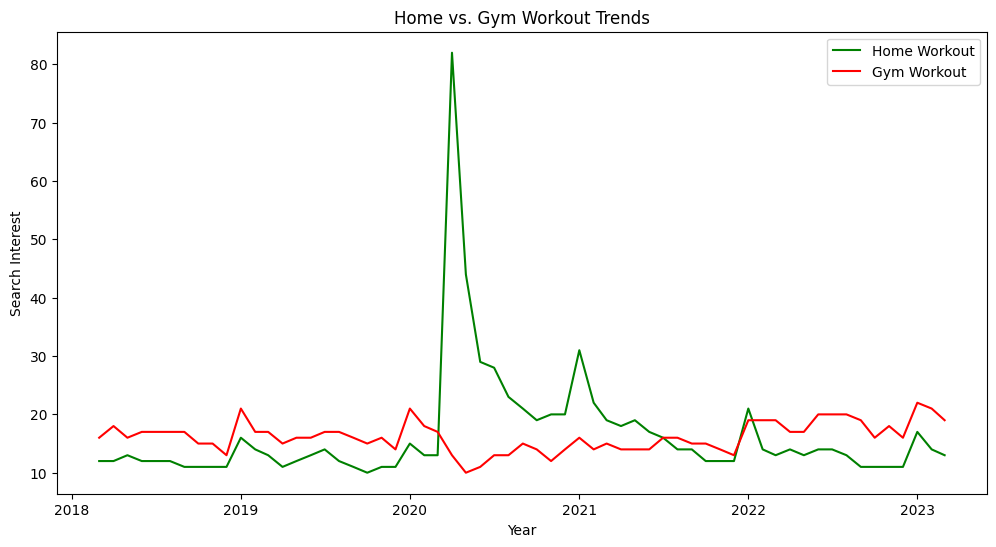

In [9]:
# Create a plot to compare Home vs. Gym
plt.figure(figsize=(12, 6))

# We use 'workout' here because it contains these specific columns for monthly data
plt.plot(workout['month'], workout['home_workout_worldwide'], label='Home Workout', color='green')
plt.plot(workout['month'], workout['gym_workout_worldwide'], label='Gym Workout', color='red')

plt.xlabel('Year')
plt.ylabel('Search Interest')
plt.title('Home vs. Gym Workout Trends')
plt.legend()
plt.show()

In [11]:
# Sort the countries by interest level (highest to lowest)
top_countries = three_keywords_geo.sort_values('workout_2018_2023', ascending=False).head(10)

# Display the top 10 countries
print(top_countries)

                 country  workout_2018_2023
5          United States              100.0
12                Canada               86.0
18             Australia               77.0
22           New Zealand               73.0
23               Lebanon               73.0
30               Ireland               69.0
31           Philippines               69.0
35             Singapore               66.0
36        United Kingdom               66.0
47  United Arab Emirates               56.0


In [13]:
# Let's see which countries are searching most for 'home_workout_2018_2023'
top_home_workout = three_keywords.sort_values('home_workout_2018_2023', ascending=False).head(5)

print("Top 5 Countries for Home Workouts:")
print(top_home_workout[['Country', 'home_workout_2018_2023']])

Top 5 Countries for Home Workouts:
         Country  home_workout_2018_2023
121         Iran                    58.0
63       Nigeria                    56.0
23   Philippines                    52.0
80   Switzerland                    52.0
130       Turkey                    52.0


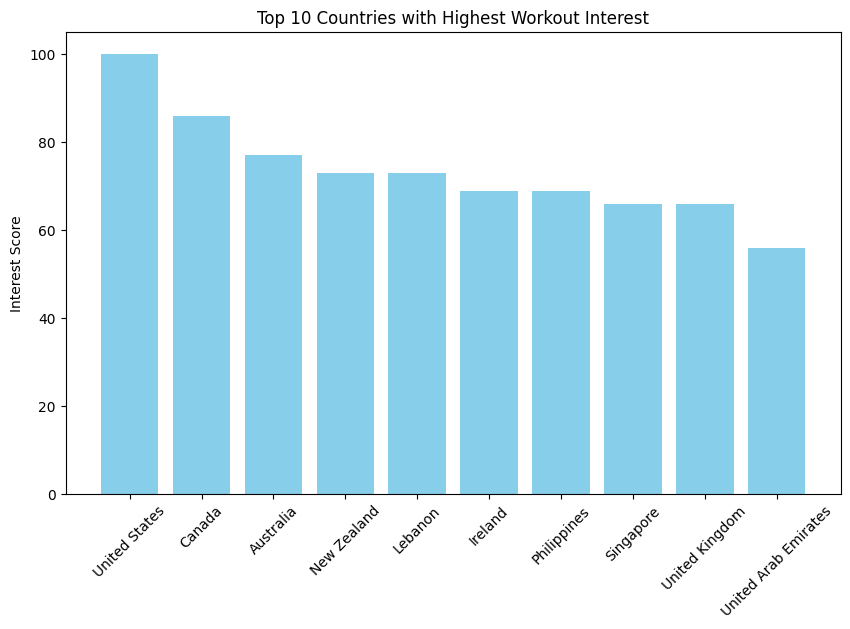

In [14]:
plt.figure(figsize=(10, 6))
plt.bar(top_countries['country'], top_countries['workout_2018_2023'], color='skyblue')

plt.xticks(rotation=45) # Tilts the country names so they don't overlap
plt.ylabel('Interest Score')
plt.title('Top 10 Countries with Highest Workout Interest')
plt.show()

In [16]:
# Create a new column that shows the difference
workout['diff'] = workout['home_workout_worldwide'] - workout['gym_workout_worldwide']

# Find the row where Home Workout had the biggest lead over Gyms
biggest_shift = workout.loc[workout['diff'].idxmax()]

print(f"The biggest surge in home workouts was in: {biggest_shift['month']}")

The biggest surge in home workouts was in: 2020-04-01 00:00:00


In [18]:
# Calculate the percentage of interest for Home vs Gym in the top countries
three_keywords['home_vs_gym_ratio'] = three_keywords['home_workout_2018_2023'] / three_keywords['gym_workout_2018_2023']

# Show countries where Home workouts are much more popular than Gyms
home_loving_countries = three_keywords.sort_values('home_vs_gym_ratio', ascending=False).head(5)

print("Top Markets for a Home Fitness App:")
print(home_loving_countries[['Country', 'home_vs_gym_ratio']])

Top Markets for a Home Fitness App:
         Country  home_vs_gym_ratio
121         Iran           2.320000
82       Belgium           2.083333
99       Germany           2.040000
80   Switzerland           2.000000
63       Nigeria           1.806452


In [20]:

home_loving_countries.to_csv('fitness_market_analysis_results.csv', index=False)



print("File saved successfully! You can find it in the folder icon on the left.")

File saved successfully! You can find it in the folder icon on the left.
